Dataset Shape: (479440, 75)
Final Feature Shape: (479440, 60)

Explained Variance per Component: [8.69562988e-01 1.30218692e-01 2.18069855e-04]
Total Variance (3 components): 0.9999997503724137


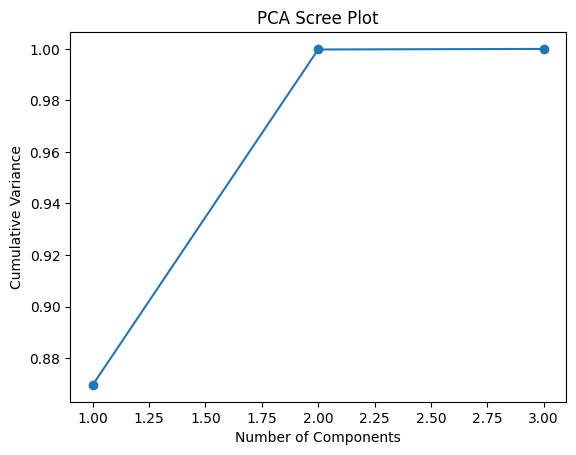

C:\Users\SAKTHI\AppData\Local\Temp\ipykernel_13292\1109219347.py:83: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


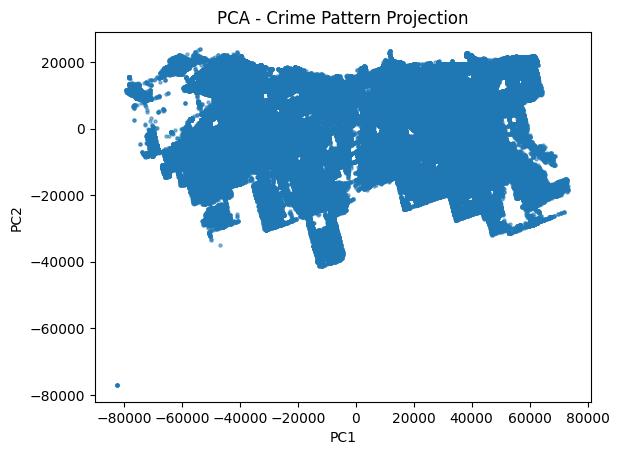


Top 5 Important Features Driving Crime Patterns:
x_coordinate    1.278034
y_coordinate    1.277734
beat            1.021093
district        0.009339
ward            0.007458
dtype: float64


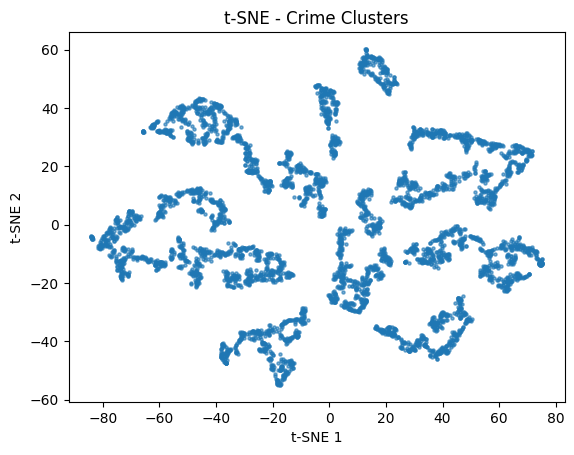

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



# Load Data


df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\feature_data\feature_dataset.csv")

print("Dataset Shape:", df.shape)



# Select ONLY MODEL-READY FEATURES
# (Drop raw + non-numeric + duplicate info)


drop_cols = [
    'id', 'case_number', 'date', 'block', 'iucr',
    'primary_type', 'description', 'location_description',
    'updated_on', 'location'
]

X = df.drop(columns=drop_cols, errors='ignore')

# Keep only numeric (important)

X = X.select_dtypes(include=[np.number])

print("Final Feature Shape:", X.shape)



# Handle Missing Values (safety)


X = X.fillna(0)



# PCA (2–3 Components)


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

explained_var = pca.explained_variance_ratio_
total_var = np.sum(explained_var)

print("\nExplained Variance per Component:", explained_var)
print("Total Variance (3 components):", total_var)



# Scree Plot


plt.figure()

plt.plot(
    range(1, len(explained_var)+1),
    np.cumsum(explained_var),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Scree Plot")

plt.show()


# PCA Scatter Plot (Cluster Visualization)


plt.figure()

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=5,
    alpha=0.5,
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Crime Pattern Projection")

plt.show()



# Feature Importance 


importance = np.abs(pca.components_).sum(axis=0)

top_features = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 5 Important Features Driving Crime Patterns:")
print(top_features.head(5))



# t-SNE


sample_size = 5000
X_sample = X.iloc[:sample_size]

tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)



# t-SNE Plot

plt.figure()

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    s=5,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - Crime Clusters")

plt.show()